<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Module-Preparation/1_NumPy_Bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy Bootcamp for Deep Learning

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**
**WMG, University of Warwick — 2026/27**

---

## Welcome

This bootcamp teaches you **every NumPy skill** you need for the Perceptron, Gradient Descent, and Artificial Neural Network sessions. No prior NumPy experience is assumed — we start from the very basics and build up to implementing a complete neural network forward pass.

### What You Will Learn

| Section | Topic | Why You Need It |
|:---|:---|:---|
| §1 | NumPy Basics (arrays, indexing, types) | Foundation for everything |
| §2 | Element-wise operations, `np.exp()`, `np.log()` | Activation functions, loss |
| §3 | Vectors, matrices, and shapes | Debugging neural networks |
| §4 | Reshaping (`np.reshape`) | Data preprocessing |
| §5 | Sigmoid, its derivative, and ReLU | Core activation functions |
| §6 | Broadcasting | Adding biases to all samples |
| §7 | Softmax | Multi-class classification |
| §8 | Row/column normalisation | Data preprocessing |
| §9 | Vectorisation vs loops | Efficient computation |
| §10 | Matrix multiplication (`@`) | Forward propagation |
| §11 | L1 and L2 loss functions | Measuring prediction error |
| §12 | Binary cross-entropy loss | Training neural networks |
| §13 | Evaluation metrics | Measuring model performance |
| §14 | Putting it all together | A complete forward pass |
| §15 | Exercises | Preparation for ANN notebook |

### Instructions

- Run each cell with **SHIFT+ENTER**.
- Write your code between `### START CODE HERE ###` and `### END CODE HERE ###`.
- Check your answers against the **Expected Output** provided.

---
## 1. NumPy Basics

**NumPy** (Numerical Python) is the core library for scientific computing in Python. In deep learning, we use NumPy instead of Python's built-in `math` library because NumPy operates on **arrays** (vectors and matrices), not just single numbers.

### 1.1 Importing NumPy

In [39]:
import numpy as np

# np is the standard alias — you will see this in every deep learning codebase
print('NumPy version:', np.__version__)

NumPy version: 2.5.3


### 1.2 Creating Arrays

A NumPy array is like a Python list, but faster and with more operations.

In [40]:
# From a Python list
a = np.array([1, 2, 3, 4, 5])
print(f'a = {a}')
print(f'Type: {type(a)}')
print(f'Data type (dtype): {a.dtype}')
print(f'Shape: {a.shape}')
print(f'Number of elements: {a.size}')

a = [1 2 3 4 5]
Type: <class 'numpy.ndarray'>
Data type (dtype): int64
Shape: (5,)
Number of elements: 5


In [3]:
# Common ways to create arrays
zeros = np.zeros(5)               # 5 zeros
ones = np.ones(3)                  # 3 ones
arange = np.arange(0, 10, 2)      # [0, 2, 4, 6, 8]
linspace = np.linspace(0, 1, 5)   # 5 evenly spaced from 0 to 1
random = np.random.randn(4)       # 4 random numbers from N(0,1)

print(f'zeros:    {zeros}')
print(f'ones:     {ones}')
print(f'arange:   {arange}')
print(f'linspace: {linspace}')
print(f'random:   {np.round(random, 4)}')

zeros:    [0. 0. 0. 0. 0.]
ones:     [1. 1. 1.]
arange:   [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
random:   [ 0.291  -1.0281  0.6542 -0.5785]


### 1.3 2D Arrays (Matrices)

In deep learning, **weight matrices** and **batches of data** are 2D arrays.

In [41]:
# Creating matrices
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print(f'M =\n{M}')
print(f'Shape: {M.shape}  → (rows, columns) = (2, 3)')
print(f'Number of rows: {M.shape[0]}')
print(f'Number of columns: {M.shape[1]}')

# Special matrices
print(f'\nZeros matrix (2x3):\n{np.zeros((2, 3))}')
print(f'\nIdentity matrix (3x3):\n{np.eye(3)}')
print(f'\nRandom matrix (2x3):\n{np.round(np.random.randn(2, 3), 3)}')

M =
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)  → (rows, columns) = (2, 3)
Number of rows: 2
Number of columns: 3

Zeros matrix (2x3):
[[0. 0. 0.]
 [0. 0. 0.]]

Identity matrix (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Random matrix (2x3):
[[ 0.543 -0.463 -0.466]
 [ 0.242 -1.913 -1.725]]


### 1.4 Indexing and Slicing

In [42]:
M = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

print(f'M =\n{M}')
print(f'\nM[0, 0] = {M[0, 0]}    (first row, first column)')
print(f'M[1, 2] = {M[1, 2]}    (second row, third column)')
print(f'M[0, :] = {M[0, :]}    (entire first row)')
print(f'M[:, 1] = {M[:, 1]}    (entire second column)')
print(f'M[0:2, 1:3] =\n{M[0:2, 1:3]}  (submatrix)')

M =
[[10 20 30]
 [40 50 60]
 [70 80 90]]

M[0, 0] = 10    (first row, first column)
M[1, 2] = 60    (second row, third column)
M[0, :] = [10 20 30]    (entire first row)
M[:, 1] = [20 50 80]    (entire second column)
M[0:2, 1:3] =
[[20 30]
 [50 60]]  (submatrix)


---
## 2. Element-wise Operations: `np.exp()`, `np.log()`, and Arithmetic

Unlike Python's `math` library, NumPy functions apply to **every element** of an array at once.

### 2.1 Why NumPy Instead of `math`?

In [43]:
import math

# math.exp works on a single number
print(f'math.exp(1) = {math.exp(1):.4f}')

# But it FAILS on a list or array:
try:
    math.exp([1, 2, 3])
except TypeError as e:
    print(f'math.exp([1,2,3]) ERROR: {e}')

# NumPy handles arrays naturally:
x = np.array([1, 2, 3])
print(f'\nnp.exp([1,2,3]) = {np.exp(x)}  ← applies to every element!')

math.exp(1) = 2.7183
math.exp([1,2,3]) ERROR: must be real number, not list

np.exp([1,2,3]) = [ 2.71828183  7.3890561  20.08553692]  ← applies to every element!


### 2.2 Key Element-wise Functions

If $\mathbf{x} = (x_1, x_2, \ldots, x_n)$, then:

- `np.exp(x)` computes $(e^{x_1}, e^{x_2}, \ldots, e^{x_n})$
- `np.log(x)` computes $(\ln x_1, \ln x_2, \ldots, \ln x_n)$
- `np.abs(x)` computes $(|x_1|, |x_2|, \ldots, |x_n|)$
- `np.sqrt(x)` computes $(\sqrt{x_1}, \sqrt{x_2}, \ldots, \sqrt{x_n})$

In [44]:
x = np.array([1, 2, 3, 4])

print(f'x        = {x}')
print(f'np.exp(x)  = {np.round(np.exp(x), 4)}')
print(f'np.log(x)  = {np.round(np.log(x), 4)}')
print(f'np.abs([-1, -2, 3]) = {np.abs(np.array([-1, -2, 3]))}')
print(f'np.sqrt(x) = {np.round(np.sqrt(x), 4)}')

x        = [1 2 3 4]
np.exp(x)  = [ 2.7183  7.3891 20.0855 54.5982]
np.log(x)  = [0.     0.6931 1.0986 1.3863]
np.abs([-1, -2, 3]) = [1 2 3]
np.sqrt(x) = [1.     1.4142 1.7321 2.    ]


### 2.3 Arithmetic Operations (Element-wise)

Adding a scalar to an array, multiplying arrays together, etc.

In [45]:
x = np.array([1, 2, 3])

# Scalar operations (apply to every element)
print(f'x + 3     = {x + 3}')
print(f'x * 2     = {x * 2}')
print(f'x ** 2    = {x ** 2}')
print(f'1 / x     = {1 / x}')

# Element-wise operations between arrays
y = np.array([10, 20, 30])
print(f'\nx + y     = {x + y}')
print(f'x * y     = {x * y}       ← element-wise multiplication')
print(f'x / y     = {x / y}')

x + 3     = [4 5 6]
x * 2     = [2 4 6]
x ** 2    = [1 4 9]
1 / x     = [1.         0.5        0.33333333]

x + y     = [11 22 33]
x * y     = [10 40 90]       ← element-wise multiplication
x / y     = [0.1 0.1 0.1]


### 2.4 `np.sum()`, `np.mean()`, `np.max()`

In [46]:
x = np.array([1, 5, 3, 8, 2])

print(f'x = {x}')
print(f'np.sum(x)  = {np.sum(x)}')
print(f'np.mean(x) = {np.mean(x)}')
print(f'np.max(x)  = {np.max(x)}')
print(f'np.min(x)  = {np.min(x)}')

# With matrices — axis matters!
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print(f'\nM =\n{M}')
print(f'np.sum(M)           = {np.sum(M)}       (sum of all elements)')
print(f'np.sum(M, axis=0)   = {np.sum(M, axis=0)}   (sum along rows → column totals)')
print(f'np.sum(M, axis=1)   = {np.sum(M, axis=1)}    (sum along columns → row totals)')
print(f'np.sum(M, axis=1, keepdims=True) =\n{np.sum(M, axis=1, keepdims=True)}  (keeps 2D shape!)')

x = [1 5 3 8 2]
np.sum(x)  = 19
np.mean(x) = 3.8
np.max(x)  = 8
np.min(x)  = 1

M =
[[1 2 3]
 [4 5 6]]
np.sum(M)           = 21       (sum of all elements)
np.sum(M, axis=0)   = [5 7 9]   (sum along rows → column totals)
np.sum(M, axis=1)   = [ 6 15]    (sum along columns → row totals)
np.sum(M, axis=1, keepdims=True) =
[[ 6]
 [15]]  (keeps 2D shape!)


### Exercise 2.1: Element-wise Operations

In [49]:
# Exercise 2.1: Compute the following without loops.

x = np.array([4, 9, 16, 25])

### START CODE HERE ### (4 lines)
# square_roots = ?       # square root of each element
# reciprocals = ?        # 1/x for each element
# log_values = ?         # natural log of each element
# total = ?              # sum of all elements
### END CODE HERE ###

# Expected output:
# square_roots = [2. 3. 4. 5.]
# reciprocals  = [0.25  0.111 0.0625 0.04]
# log_values   = [1.386 2.197 2.773 3.219]
# total        = 54

---
## 3. Vectors, Matrices, and Shapes

Understanding shapes is the **single most important debugging skill** in deep learning.

### 3.1 Shape Terminology

| Term | Shape | Example | DL Context |
|:---|:---|:---|:---|
| Scalar | `()` | `5.0` | The loss value |
| 1D array (avoid!) | `(n,)` | `[1, 2, 3]` | Ambiguous — avoid in DL code |
| Column vector | `(n, 1)` | `[[1], [2], [3]]` | One sample's features |
| Row vector | `(1, n)` | `[[1, 2, 3]]` | One neuron's weights |
| Matrix | `(m, n)` | 2D grid | Weight matrix, data batch |

### 3.2 The Rank-1 Array Pitfall

A shape of `(3,)` is a **rank-1 array** — it is neither a row vector nor a column vector. This causes subtle bugs. **Always use explicit 2D shapes.**

In [50]:
# The dangerous rank-1 array
a = np.array([1, 2, 3])
print(f'a = {a}')
print(f'a.shape = {a.shape}      ← rank-1 array (NOT a row or column vector!)')
print(f'a.T = {a.T}')
print(f'a.T.shape = {a.T.shape}  ← transpose does NOTHING on rank-1!')

print()

# The safe column vector
b = np.array([[1], [2], [3]])
print(f'b =\n{b}')
print(f'b.shape = {b.shape}    ← proper column vector')
print(f'b.T = {b.T}')
print(f'b.T.shape = {b.T.shape}  ← transpose works correctly!')

print()

# Converting rank-1 to proper vector
a_col = a.reshape(-1, 1)  # make it (3, 1)
a_row = a.reshape(1, -1)  # make it (1, 3)
print(f'a.reshape(-1, 1).shape = {a_col.shape}  (column vector)')
print(f'a.reshape(1, -1).shape = {a_row.shape}  (row vector)')

a = [1 2 3]
a.shape = (3,)      ← rank-1 array (NOT a row or column vector!)
a.T = [1 2 3]
a.T.shape = (3,)  ← transpose does NOTHING on rank-1!

b =
[[1]
 [2]
 [3]]
b.shape = (3, 1)    ← proper column vector
b.T = [[1 2 3]]
b.T.shape = (1, 3)  ← transpose works correctly!

a.reshape(-1, 1).shape = (3, 1)  (column vector)
a.reshape(1, -1).shape = (1, 3)  (row vector)


### 3.3 Our Shape Convention

In this module, we use:

$$\mathbf{X} \text{ has shape } (n_{\text{features}},\; m_{\text{samples}})$$

Each **column** is one sample. This makes matrix multiplication clean for forward propagation.

### Exercise 3.1: Fix the shapes

In [12]:
# Exercise 3.1: Convert each rank-1 array to the specified shape.

v = np.array([4, 5, 6, 7])

### START CODE HERE ###
# col = ?   # shape should be (4, 1)
# row = ?   # shape should be (1, 4)
### END CODE HERE ###

# Uncomment to check:
# print(f'col.shape = {col.shape}')  # Expected: (4, 1)
# print(f'row.shape = {row.shape}')  # Expected: (1, 4)

---
## 4. Reshaping Arrays with `np.reshape()`

Reshaping is used constantly in deep learning — for example, converting an image from a 3D array (height × width × channels) into a 1D vector to feed into a neural network.

### 4.1 Basic Reshaping

In [13]:
v = np.arange(12)  # [0, 1, 2, ..., 11]
print(f'Original: {v}, shape = {v.shape}')

# Reshape into different 2D shapes
print(f'\nReshaped (3, 4):\n{v.reshape(3, 4)}')
print(f'\nReshaped (4, 3):\n{v.reshape(4, 3)}')
print(f'\nReshaped (2, 6):\n{v.reshape(2, 6)}')

# Using -1: "figure out this dimension for me"
print(f'\nv.reshape(-1, 1) shape: {v.reshape(-1, 1).shape}  (12x1 column)')
print(f'v.reshape(1, -1) shape: {v.reshape(1, -1).shape}  (1x12 row)')
print(f'v.reshape(3, -1) shape: {v.reshape(3, -1).shape}  (3 rows, auto cols)')

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11], shape = (12,)

Reshaped (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshaped (4, 3):
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

Reshaped (2, 6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]

v.reshape(-1, 1) shape: (12, 1)  (12x1 column)
v.reshape(1, -1) shape: (1, 12)  (1x12 row)
v.reshape(3, -1) shape: (3, 4)  (3 rows, auto cols)


### 4.2 Image Flattening (Common in Deep Learning)

An image of shape `(height, width, 3)` needs to be reshaped into a single column vector `(height*width*3, 1)` before feeding it to a neural network.

In [14]:
# Simulating a tiny 3x3 RGB image
image = np.random.rand(3, 3, 3)  # height=3, width=3, channels=3 (RGB)
print(f'Image shape: {image.shape}')
print(f'Total pixels × channels: {image.shape[0] * image.shape[1] * image.shape[2]}')

# Flatten to a column vector
v = image.reshape(-1, 1)
print(f'Flattened shape: {v.shape}')
print(f'First 5 values: {v[:5, 0].round(4)}')

Image shape: (3, 3, 3)
Total pixels × channels: 27
Flattened shape: (27, 1)
First 5 values: [0.8522 0.577  0.9907 0.7437 0.463 ]


### Exercise 4.1: Implement `image2vector()`

In [15]:
# Exercise 4.1: Flatten an image into a column vector.

def image2vector(image):
    """
    Argument: image -- numpy array of shape (length, height, depth)
    Returns: v -- vector of shape (length*height*depth, 1)
    """
    ### START CODE HERE ### (1 line)

    ### END CODE HERE ###
    return v

# Test
image = np.array([[[0.68, 0.29], [0.91, 0.53], [0.42, 0.45]],
                   [[0.93, 0.97], [0.85, 0.52], [0.20, 0.27]],
                   [[0.61, 0.01], [0.11, 0.50], [0.34, 0.95]]])
print(f'image2vector(image).shape = {image2vector(image).shape}')
# Expected: (18, 1)

image2vector(image).shape = (27, 1)


---
## 5. Sigmoid Function, Its Derivative, and ReLU

These are the **activation functions** used in neural networks. They introduce non-linearity, which is essential for learning complex patterns.

### 5.1 Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

The sigmoid function squashes any input into the range $(0, 1)$, making it useful for binary classification (interpreting output as a probability).

### 5.2 Sigmoid Derivative

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

We need the derivative for **gradient descent** — it tells us how to adjust the weights.

In [16]:
def sigmoid(x):
    """
    Compute sigmoid of x. Works for scalars, vectors, and matrices.
    Arguments: x -- a numpy array of any size
    Returns: s -- sigmoid(x)
    """
    s = 1 / (1 + np.exp(-x))
    return s

# Test on different inputs
print(f'sigmoid(0)   = {sigmoid(0):.4f}     (should be 0.5)')
print(f'sigmoid(5)   = {sigmoid(5):.4f}  (close to 1)')
print(f'sigmoid(-5)  = {sigmoid(-5):.4f}  (close to 0)')

x = np.array([1, 2, 3])
print(f'sigmoid([1,2,3]) = {sigmoid(x).round(8)}')

sigmoid(0)   = 0.5000     (should be 0.5)
sigmoid(5)   = 0.9933  (close to 1)
sigmoid(-5)  = 0.0067  (close to 0)
sigmoid([1,2,3]) = [0.73105858 0.88079708 0.95257413]


### Exercise 5.1: Implement `sigmoid_derivative()`

In [17]:
# Exercise 5.1: Compute the gradient of the sigmoid function.
# Formula: sigmoid_derivative(x) = sigmoid(x) * (1 - sigmoid(x))

def sigmoid_derivative(x):
    """
    Compute the gradient of sigmoid with respect to x.
    Arguments: x -- a scalar or numpy array
    Returns: ds -- the computed gradient
    """
    ### START CODE HERE ### (2 lines)

    ### END CODE HERE ###
    return None  # Replace with: return ds

# Test
x = np.array([1, 2, 3])
print(f'sigmoid_derivative([1,2,3]) = {sigmoid_derivative(x)}')
# Expected: [0.19661193  0.10499359  0.04517666]

sigmoid_derivative([1,2,3]) = None


### 5.3 ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x), \qquad \text{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \le 0 \end{cases}$$

ReLU is the **default activation** for hidden layers in modern neural networks. It is simple, fast, and avoids the vanishing gradient problem that affects sigmoid in deep networks.

In [18]:
def relu(x):
    """ReLU activation: max(0, x) element-wise."""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU."""
    return (x > 0).astype(float)

x = np.array([-3, -1, 0, 1, 3])
print(f'x            = {x}')
print(f'relu(x)      = {relu(x)}')
print(f"relu'(x)     = {relu_derivative(x)}")

x            = [-3 -1  0  1  3]
relu(x)      = [0 0 0 1 3]
relu'(x)     = [0. 0. 0. 1. 1.]


### Visualising Sigmoid vs ReLU

Matplotlib is building the font cache; this may take a moment.


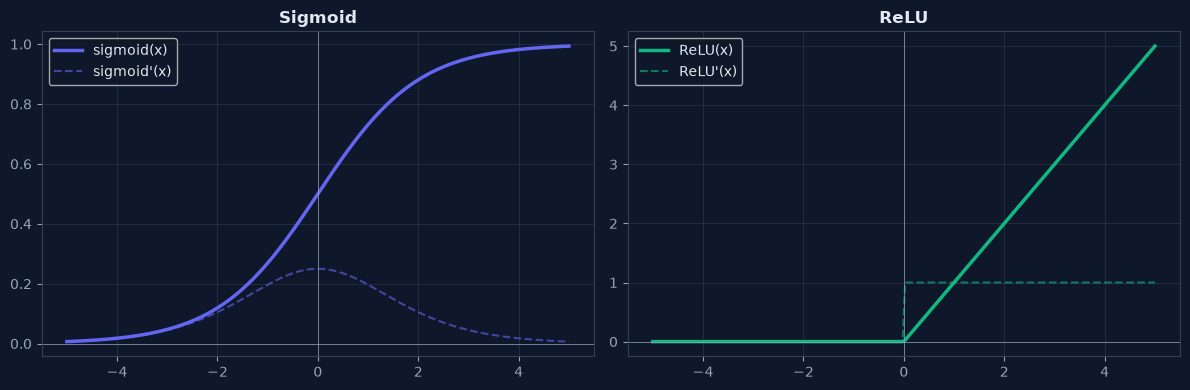

In [19]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 4), 'axes.facecolor': '#0F172A',
    'figure.facecolor': '#0F172A', 'text.color': '#E2E8F0',
    'axes.labelcolor': '#E2E8F0', 'xtick.color': '#94A3B8',
    'ytick.color': '#94A3B8', 'axes.edgecolor': '#334155',
    'grid.color': '#334155', 'grid.alpha': 0.5,
})

x = np.linspace(-5, 5, 200)
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(x, sigmoid(x), color='#6366F1', linewidth=2.5, label='sigmoid(x)')
ax1.plot(x, sigmoid(x) * (1 - sigmoid(x)), '--', color='#6366F1', alpha=0.6, label="sigmoid'(x)")
ax1.set_title('Sigmoid', fontweight='bold'); ax1.legend(); ax1.grid(True)
ax1.axhline(0, color='#94A3B8', lw=0.5); ax1.axvline(0, color='#94A3B8', lw=0.5)

ax2.plot(x, relu(x), color='#10B981', linewidth=2.5, label='ReLU(x)')
ax2.plot(x, relu_derivative(x), '--', color='#10B981', alpha=0.6, label="ReLU'(x)")
ax2.set_title('ReLU', fontweight='bold'); ax2.legend(); ax2.grid(True)
ax2.axhline(0, color='#94A3B8', lw=0.5); ax2.axvline(0, color='#94A3B8', lw=0.5)

plt.tight_layout(); plt.show()

---
## 6. Broadcasting

**Broadcasting** is one of the most important concepts in NumPy. It allows operations on arrays of **different shapes** without explicit loops. In neural networks, broadcasting is how we add a bias vector to every sample simultaneously.

### Rules
NumPy compares shapes from the **rightmost** dimension:
1. Dimensions are compatible if they are **equal** or one of them is **1**.
2. Arrays with fewer dimensions are padded with 1s on the left.

### Example: Adding bias to all samples

$$\underbrace{\mathbf{Z}}_{(2, 4)} + \underbrace{\mathbf{b}}_{(2, 1)} = \underbrace{\text{result}}_{(2, 4)}$$

The bias vector $\mathbf{b}$ is automatically added to **every column** of $\mathbf{Z}$.

In [20]:
# Broadcasting in action
Z = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8]])   # (2, 4) — 2 neurons, 4 samples

b = np.array([[10],
              [20]])            # (2, 1) — 2 biases

result = Z + b

print(f'Z shape:     {Z.shape}')
print(f'b shape:     {b.shape}')
print(f'Z + b shape: {result.shape}')
print(f'\nZ =\n{Z}')
print(f'b = {b.ravel()}')
print(f'Z + b =\n{result}')
print(f'\n→ Each column had b added to it (broadcasting!)')

Z shape:     (2, 4)
b shape:     (2, 1)
Z + b shape: (2, 4)

Z =
[[1 2 3 4]
 [5 6 7 8]]
b = [10 20]
Z + b =
[[11 12 13 14]
 [25 26 27 28]]

→ Each column had b added to it (broadcasting!)


In [21]:
# More broadcasting examples
x = np.array([[1, 2, 3]])       # (1, 3) — row vector
y = np.array([[10], [20]])       # (2, 1) — column vector

result = x + y   # (1,3) + (2,1) = (2,3) — both are broadcast!
print(f'(1,3) + (2,1) = {result.shape}')
print(f'Result:\n{result}')

# Scalar broadcast
M = np.array([[1, 2], [3, 4]])
print(f'\nM * 0.01 =\n{M * 0.01}  ← scalar broadcasts to every element')

(1,3) + (2,1) = (2, 3)
Result:
[[11 12 13]
 [21 22 23]]

M * 0.01 =
[[0.01 0.02]
 [0.03 0.04]]  ← scalar broadcasts to every element


### Exercise 6.1: Predict the result, then verify

In [22]:
# Exercise 6.1: What is the shape of each result?
# Write your prediction as a comment, then run.

A = np.random.randn(3, 4)   # (3, 4)
b = np.random.randn(3, 1)   # (3, 1)
c = np.random.randn(1, 4)   # (1, 4)

# Prediction: A + b = shape ?
print(f'A + b: {(A + b).shape}')

# Prediction: A * c = shape ?
print(f'A * c: {(A * c).shape}')

# Prediction: b + c = shape ?
print(f'b + c: {(b + c).shape}')

A + b: (3, 4)
A * c: (3, 4)
b + c: (3, 4)


---
## 7. Softmax Function

Softmax converts a vector of raw scores (logits) into **probabilities** that sum to 1. It is used as the output activation for **multi-class classification**.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

### Numerical Stability Trick

Computing $e^{z_i}$ can overflow for large $z$. We subtract the maximum: $e^{z_i - \max(z)}$. This gives the same result but avoids overflow.

In [23]:
def softmax(x):
    """
    Compute softmax for each column of x.
    x shape: (classes, samples)
    Returns: same shape, each column sums to 1.
    """
    e_x = np.exp(x - np.max(x, axis=0, keepdims=True))  # stability trick
    return e_x / np.sum(e_x, axis=0, keepdims=True)

# Test with a single sample (column vector)
z = np.array([[2], [1], [0.1]])
s = softmax(z)
print(f'Input z:       {z.ravel()}')
print(f'softmax(z):    {s.ravel().round(4)}')
print(f'Sum:           {s.sum():.4f}  (should be 1.0)')

# Test with a batch of 2 samples
z_batch = np.array([[9, 7],
                     [2, 5],
                     [5, 0]])
s_batch = softmax(z_batch)
print(f'\nBatch softmax:\n{s_batch.round(4)}')
print(f'Column sums: {s_batch.sum(axis=0).round(4)}  (each should be 1.0)')

Input z:       [2.  1.  0.1]
softmax(z):    [0.659  0.2424 0.0986]
Sum:           1.0000  (should be 1.0)

Batch softmax:
[[9.811e-01 8.801e-01]
 [9.000e-04 1.191e-01]
 [1.800e-02 8.000e-04]]
Column sums: [1. 1.]  (each should be 1.0)


---
## 8. Row Normalisation

Normalising data (scaling it to have unit length or zero mean) often improves training. Here we normalise each **row** of a matrix to have unit length (L2 norm).

$$x_{\text{normalised}} = \frac{x}{\|x\|_2}$$

where $\|x\|_2 = \sqrt{\sum x_i^2}$.

In [24]:
def normalise_rows(x):
    """Normalise each row of x to have unit L2 norm."""
    norms = np.linalg.norm(x, axis=1, keepdims=True)  # (rows, 1)
    return x / norms

x = np.array([[0, 3, 4],
              [1, 6, 4]])

print(f'Before normalisation:\n{x}')
x_norm = normalise_rows(x)
print(f'\nAfter normalisation:\n{x_norm.round(5)}')
print(f'\nRow norms after: {np.linalg.norm(x_norm, axis=1).round(4)}  (should be [1, 1])')

Before normalisation:
[[0 3 4]
 [1 6 4]]

After normalisation:
[[0.      0.6     0.8    ]
 [0.13736 0.82416 0.54944]]

Row norms after: [1. 1.]  (should be [1, 1])


---
## 9. Vectorisation vs Loops

In deep learning, datasets have millions of samples. **Vectorised** NumPy operations are 100–1000× faster than Python loops because they use optimised C code internally.

### Rule: Avoid explicit for-loops over data whenever possible.

In [25]:
import time

# Create large vectors
n = 1_000_000
x1 = np.random.rand(n)
x2 = np.random.rand(n)

# === LOOP VERSION ===
tic = time.time()
dot_loop = 0
for i in range(n):
    dot_loop += x1[i] * x2[i]
toc = time.time()
loop_time = (toc - tic) * 1000

# === VECTORISED VERSION ===
tic = time.time()
dot_vec = np.dot(x1, x2)
toc = time.time()
vec_time = (toc - tic) * 1000

print(f'Loop version:       {dot_loop:.4f}  ({loop_time:.1f} ms)')
print(f'Vectorised version: {dot_vec:.4f}  ({vec_time:.2f} ms)')
print(f'\nSpeedup: {loop_time / max(vec_time, 0.001):.0f}x faster!')
print(f'\n→ ALWAYS use vectorised operations in deep learning.')

Loop version:       249936.3626  (356.2 ms)
Vectorised version: 249936.3626  (2.40 ms)

Speedup: 149x faster!

→ ALWAYS use vectorised operations in deep learning.


### Key Vectorised Patterns

| Loop Version | Vectorised Version |
|:---|:---|
| `for i: sum += x[i] * y[i]` | `np.dot(x, y)` |
| `for i: result[i] = x[i] ** 2` | `x ** 2` |
| `for i: result[i] = f(x[i])` | `f(x)` (NumPy functions) |
| `for i: result += abs(x[i])` | `np.sum(np.abs(x))` |

---
## 10. Matrix Multiplication — The Core of Forward Propagation

**This is the most important section.** Forward propagation in a neural network is just repeated matrix multiplication followed by activation functions.

### 10.1 The Rule

$$\mathbf{A} \in \mathbb{R}^{m \times n}, \quad \mathbf{B} \in \mathbb{R}^{n \times p} \quad \Rightarrow \quad \mathbf{C} = \mathbf{A} \mathbf{B} \in \mathbb{R}^{m \times p}$$

The **inner dimensions must match**: $(m, \mathbf{n}) \times (\mathbf{n}, p) = (m, p)$.

### 10.2 In a Neural Network Layer

$$\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}$$

- $\mathbf{W}$: weight matrix, shape $(n_{\text{neurons}}, n_{\text{inputs}})$
- $\mathbf{x}$: input, shape $(n_{\text{inputs}}, m_{\text{samples}})$
- $\mathbf{b}$: bias, shape $(n_{\text{neurons}}, 1)$ — broadcast across samples
- $\mathbf{z}$: output, shape $(n_{\text{neurons}}, m_{\text{samples}})$

In [26]:
# Matrix multiplication with @
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])      # (3, 2)
B = np.array([[7, 8, 9],
              [10, 11, 12]])  # (2, 3)

C = A @ B  # (3,2) @ (2,3) = (3,3)
print(f'A: {A.shape}, B: {B.shape}, C = A @ B: {C.shape}')
print(f'C =\n{C}')

# Manual check: C[0,0] = 1*7 + 2*10 = 27
print(f'\nManual: C[0,0] = 1*7 + 2*10 = {1*7 + 2*10} ← matches {C[0,0]}')

A: (3, 2), B: (2, 3), C = A @ B: (3, 3)
C =
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]

Manual: C[0,0] = 1*7 + 2*10 = 27 ← matches 27


### 10.3 Simulating a Neural Network Layer

In [27]:
# One layer: 3 inputs -> 2 neurons
x = np.array([[0.5], [0.8], [0.2]])   # (3, 1) — one sample
W = np.array([[0.4, 0.6, -0.3],
              [0.1, -0.5, 0.8]])       # (2, 3)
b = np.array([[0.1], [-0.2]])           # (2, 1)

# Forward pass
z = W @ x + b   # (2,3) @ (3,1) + (2,1) = (2,1)
a = sigmoid(z)

print(f'z = W @ x + b = {z.ravel().round(4)}')
print(f'a = sigmoid(z) = {a.ravel().round(4)}')

# Manual verification
z0 = 0.4*0.5 + 0.6*0.8 + (-0.3)*0.2 + 0.1
z1 = 0.1*0.5 + (-0.5)*0.8 + 0.8*0.2 + (-0.2)
print(f'\nManual: z[0] = {z0}, z[1] = {z1}')

z = W @ x + b = [ 0.72 -0.39]
a = sigmoid(z) = [0.6726 0.4037]

Manual: z[0] = 0.7199999999999999, z[1] = -0.39


### 10.4 Batch Processing (Multiple Samples at Once)

In [28]:
# Processing 4 samples simultaneously
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])   # (2, 4) — 2 features, 4 samples

W = np.array([[0.3, -0.5],
              [0.7,  0.2]])    # (2, 2) — 2 neurons, 2 inputs
b = np.array([[0.1], [-0.1]])  # (2, 1)

Z = W @ X + b  # (2,2) @ (2,4) + (2,1) = (2,4)  ← broadcasting adds b to each column
A = sigmoid(Z)

print(f'X shape: {X.shape} (features x samples)')
print(f'W shape: {W.shape} (neurons x inputs)')
print(f'b shape: {b.shape} (neurons x 1)')
print(f'Z = W@X + b: {Z.shape} (neurons x samples)')
print(f'A = sigmoid(Z): {A.shape}')
print(f'\nPredictions for each sample:\n{A.round(4)}')

X shape: (2, 4) (features x samples)
W shape: (2, 2) (neurons x inputs)
b shape: (2, 1) (neurons x 1)
Z = W@X + b: (2, 4) (neurons x samples)
A = sigmoid(Z): (2, 4)

Predictions for each sample:
[[0.525  0.4013 0.5987 0.475 ]
 [0.475  0.525  0.6457 0.69  ]]


### Exercise 10.1: Two-Layer Forward Pass

In [29]:
# Exercise 10.1: Implement forward propagation through two layers.

def two_layer_forward(X, W1, b1, W2, b2):
    """
    X: input, shape (n_in, m)
    W1, b1: hidden layer params
    W2, b2: output layer params
    Returns: A2 (predictions), shape (n_out, m)
    """
    ### START CODE HERE ### (4 lines)
    # Z1 = ?
    # A1 = ?
    # Z2 = ?
    # A2 = ?
    ### END CODE HERE ###
    return A2

# Test:
# np.random.seed(42)
# X = np.array([[0,0,1,1],[0,1,0,1]])  # (2,4)
# W1 = np.random.randn(3, 2) * 0.5; b1 = np.zeros((3,1))
# W2 = np.random.randn(1, 3) * 0.5; b2 = np.zeros((1,1))
# output = two_layer_forward(X, W1, b1, W2, b2)
# print(f'Output shape: {output.shape}')  # Expected: (1, 4)

---
## 11. L1 and L2 Loss Functions

Loss functions measure how far our predictions are from the true values.

### L1 Loss (Mean Absolute Error)

$$L_1 = \frac{1}{m} \sum_{i=1}^{m} |y^{(i)} - \hat{y}^{(i)}|$$

### L2 Loss (Mean Squared Error)

$$L_2 = \frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2$$

L2 penalises large errors more heavily than L1 because of the squaring.

In [30]:
def L1_loss(y_hat, y):
    """L1 loss (mean absolute error)."""
    return np.mean(np.abs(y - y_hat))

def L2_loss(y_hat, y):
    """L2 loss (mean squared error)."""
    return np.mean((y - y_hat) ** 2)

y_hat = np.array([0.9, 0.2, 0.1, 0.4, 0.9])
y     = np.array([1.0, 0.0, 0.0, 1.0, 1.0])

print(f'Predictions: {y_hat}')
print(f'True labels: {y}')
print(f'L1 loss: {L1_loss(y_hat, y):.4f}')
print(f'L2 loss: {L2_loss(y_hat, y):.4f}')

Predictions: [0.9 0.2 0.1 0.4 0.9]
True labels: [1. 0. 0. 1. 1.]
L1 loss: 0.2200
L2 loss: 0.0860


### Exercise 11.1: Implement L1 and L2 loss using vectorised operations (no loops!)

In [31]:
# Exercise 11.1

def L1(yhat, y):
    ### START CODE HERE ### (1 line)
    loss = None
    ### END CODE HERE ###
    return loss

def L2(yhat, y):
    ### START CODE HERE ### (1 line)
    loss = None
    ### END CODE HERE ###
    return loss

# Test:
# yhat = np.array([.9, 0.2, 0.1, .4, .9])
# y = np.array([1, 0, 0, 1, 1])
# print(f'L1 = {L1(yhat, y)}')   # Expected: 0.22
# print(f'L2 = {L2(yhat, y)}')   # Expected: 0.086

---
## 12. Binary Cross-Entropy Loss

This is the loss function used to train neural networks for **binary classification**. It heavily penalises confident wrong predictions (predicting 0.99 when the true label is 0).

$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Note: We use `np.clip()` to prevent `log(0)`, which would give `-inf`.

In [32]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

y = np.array([1, 0, 1, 0, 1])
y_good  = np.array([0.9, 0.1, 0.8, 0.2, 0.95])
y_bad   = np.array([0.5, 0.5, 0.5, 0.5, 0.5])
y_awful = np.array([0.1, 0.9, 0.2, 0.8, 0.1])

print(f'BCE (good predictions):   {binary_cross_entropy(y, y_good):.4f}')
print(f'BCE (random predictions): {binary_cross_entropy(y, y_bad):.4f}')
print(f'BCE (awful predictions):  {binary_cross_entropy(y, y_awful):.4f}')
print(f'\n→ Better predictions give LOWER loss.')

BCE (good predictions):   0.1417
BCE (random predictions): 0.6931
BCE (awful predictions):  2.0253

→ Better predictions give LOWER loss.


---
## 13. Evaluation Metrics

After training a model, we evaluate its performance using metrics beyond just loss.

### Confusion Matrix

$$\begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}$$

### Metrics

$$\text{Accuracy} = \frac{TP + TN}{N}, \quad \text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}, \quad \text{F1} = \frac{2PR}{P+R}$$

In [33]:
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0])

# Boolean masks — no loops needed!
TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == 0) & (y_true == 0))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

accuracy  = (TP + TN) / len(y_true)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

TP=4, TN=4, FP=1, FN=1
Accuracy:  0.8000
Precision: 0.8000
Recall:    0.8000
F1-Score:  0.8000


---
## 14. Putting It All Together: A Complete Forward Pass

This section uses **every skill from the bootcamp** to perform forward propagation through a 2-layer neural network on the XOR problem.

In [34]:
# === DATA ===
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])   # (2, 4)
Y = np.array([[0, 1, 1, 0]])   # (1, 4)

# === INITIALISE WEIGHTS ===
np.random.seed(42)
W1 = np.random.randn(3, 2) * 0.5   # (3, 2) — 3 hidden, 2 inputs
b1 = np.zeros((3, 1))               # (3, 1)
W2 = np.random.randn(1, 3) * 0.5   # (1, 3) — 1 output, 3 hidden
b2 = np.zeros((1, 1))               # (1, 1)

print('=== Shapes ===')
print(f'X:  {X.shape},  W1: {W1.shape},  b1: {b1.shape}')
print(f'             W2: {W2.shape},  b2: {b2.shape}')
print(f'Total params: {W1.size + b1.size + W2.size + b2.size}')

# === FORWARD PROPAGATION ===
# Layer 1: hidden
Z1 = W1 @ X + b1          # (3,2)@(2,4) + (3,1) = (3,4) — broadcasting!
A1 = sigmoid(Z1)            # (3,4)

# Layer 2: output
Z2 = W2 @ A1 + b2         # (1,3)@(3,4) + (1,1) = (1,4) — broadcasting!
A2 = sigmoid(Z2)            # (1,4)

# === LOSS ===
loss = binary_cross_entropy(Y, A2)

# === METRICS ===
preds = (A2 >= 0.5).astype(int)
accuracy = np.mean(preds == Y)

print(f'\n=== Results ===')
print(f'Predictions:  {A2.round(4)}')
print(f'True labels:  {Y}')
print(f'Hard preds:   {preds}')
print(f'BCE Loss:     {loss:.4f}')
print(f'Accuracy:     {accuracy:.0%}')
print(f'\n(Random weights → poor predictions. Training will fix this!)')

=== Shapes ===
X:  (2, 4),  W1: (3, 2),  b1: (3, 1)
             W2: (1, 3),  b2: (1, 1)
Total params: 13

=== Results ===
Predictions:  [[0.6152 0.63   0.6355 0.6487]]
True labels:  [[0 1 1 0]]
Hard preds:   [[1 1 1 1]]
BCE Loss:     0.7291
Accuracy:     50%

(Random weights → poor predictions. Training will fix this!)


---
## 15. Capstone Exercises

These exercises bring together everything from this bootcamp. They directly prepare you for the Perceptron and ANN notebooks.

### Exercise 15.1: Implement a Single Neuron

In [35]:
def single_neuron(x, w, b, activation='sigmoid'):
    """
    x: input, shape (n, 1)
    w: weights, shape (1, n)
    b: bias, scalar
    activation: 'sigmoid' or 'relu'
    Returns: output, scalar
    """
    ### START CODE HERE ###

    ### END CODE HERE ###
    pass

# Test:
# x = np.array([[0.5], [0.8], [0.2]])
# w = np.array([[0.4, 0.6, -0.3]])
# print(single_neuron(x, w, 0.1, 'sigmoid'))

### Exercise 15.2: Parameter Counting

For a network with layers [5, 10, 3, 1], calculate the total parameters by hand, then verify:

In [36]:
def count_params(layers):
    total = 0
    for l in range(1, len(layers)):
        total += layers[l] * layers[l-1] + layers[l]
    return total

### START CODE HERE ###
# hand_calculation = ?
### END CODE HERE ###

print(f'[5, 10, 3, 1] parameters: {count_params([5, 10, 3, 1])}')
# Your hand calculation should match!

[5, 10, 3, 1] parameters: 97


### Exercise 15.3: Compute Evaluation Metrics

In [37]:
def compute_metrics(y_true, y_pred):
    """Return dict with accuracy, precision, recall, f1."""
    ### START CODE HERE ###

    ### END CODE HERE ###
    pass

# Test:
# m = compute_metrics(np.array([1,0,1,1,0]), np.array([1,0,0,1,0]))
# print(m)  # accuracy=0.8, precision=1.0, recall=0.667, f1=0.8

### Exercise 15.4: Complete Forward Pass Function

In [38]:
def forward_pass(X, params):
    """
    X: input, shape (n_in, m)
    params: dict with 'W1','b1','W2','b2'
    Returns: predictions shape (1, m)
    """
    ### START CODE HERE ###

    ### END CODE HERE ###
    pass

# Test:
# np.random.seed(42)
# params = {
#     'W1': np.random.randn(4, 2)*0.5, 'b1': np.zeros((4,1)),
#     'W2': np.random.randn(1, 4)*0.5, 'b2': np.zeros((1,1))
# }
# X = np.array([[0,0,1,1],[0,1,0,1]])
# out = forward_pass(X, params)
# print(f'Shape: {out.shape}, Values: {out.round(4)}')

---
## Summary — Your NumPy Toolkit for Deep Learning

| Skill | Function / Syntax | Used In |
|:---|:---|:---|
| Create arrays | `np.array()`, `np.zeros()`, `np.random.randn()` | Weight initialisation |
| Element-wise math | `np.exp()`, `np.log()`, `+`, `*`, `**` | Activations, loss |
| Aggregation | `np.sum()`, `np.mean()`, `np.max()` | Loss, normalisation |
| Shapes | `.shape`, `.reshape(-1, 1)` | Debugging everything |
| Matrix multiply | `A @ B` or `np.dot(A, B)` | Forward propagation |
| Broadcasting | `Z + b` where shapes differ | Bias addition |
| Sigmoid | `1 / (1 + np.exp(-z))` | Activation function |
| ReLU | `np.maximum(0, z)` | Activation function |
| Softmax | `exp(z) / sum(exp(z))` | Multi-class output |
| Clipping | `np.clip(y, eps, 1-eps)` | Prevent log(0) |
| Boolean ops | `(y_pred == 1) & (y_true == 1)` | Confusion matrix |

You are now ready for the **Perceptron** and **ANN Forward Propagation** notebooks!

---
*MSc Applied AI — WMG, University of Warwick — 2025/26*